In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
movies_path ="/content/tmdb_5000_movies.csv"
credits_path ="/content/tmdb_5000_credits.csv"

In [3]:
movies = pd.read_csv(movies_path)
credits = pd.read_csv(credits_path)

In [4]:
print(movies.shape)
print(credits.shape)

(4803, 20)
(4803, 4)


In [5]:
print(movies.head())
print(credits.head())

      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "nam

In [7]:
print(movies.describe())
print(credits.describe())

             budget             id   popularity       revenue      runtime  \
count  4.803000e+03    4803.000000  4803.000000  4.803000e+03  4801.000000   
mean   2.904504e+07   57165.484281    21.492301  8.226064e+07   106.875859   
std    4.072239e+07   88694.614033    31.816650  1.628571e+08    22.611935   
min    0.000000e+00       5.000000     0.000000  0.000000e+00     0.000000   
25%    7.900000e+05    9014.500000     4.668070  0.000000e+00    94.000000   
50%    1.500000e+07   14629.000000    12.921594  1.917000e+07   103.000000   
75%    4.000000e+07   58610.500000    28.313505  9.291719e+07   118.000000   
max    3.800000e+08  459488.000000   875.581305  2.787965e+09   338.000000   

       vote_average    vote_count  
count   4803.000000   4803.000000  
mean       6.092172    690.217989  
std        1.194612   1234.585891  
min        0.000000      0.000000  
25%        5.600000     54.000000  
50%        6.200000    235.000000  
75%        6.800000    737.000000  
max      

In [9]:
#data cleaning nd preprocessing
#handling missing values
print(movies.isnull().sum())
print(credits.isnull().sum())

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64
movie_id    0
title       0
cast        0
crew        0
dtype: int64


In [11]:
import ast

def parse_genres(genre_string):
    try:
        # Safely evaluate the string to a Python literal
        evaluated_data = ast.literal_eval(genre_string)
        # Check if the result is a list of dictionaries as expected
        if isinstance(evaluated_data, list):
            # Extract 'name' from each dictionary
            return [d['name'] for d in evaluated_data if isinstance(d, dict) and 'name' in d]
        else:
            # If it's not a list, return an empty list
            return []
    except (ValueError, SyntaxError):
        # Catch errors from ast.literal_eval for malformed strings
        return []
    except TypeError:
        # Catch TypeError if genre_string is not a string (e.g., NaN, None)
        return []

movies["genres"] = movies["genres"].apply(parse_genres)

In [12]:
#data visualization
#top 10 highest rated movies
top_10_rated_movies = movies.sort_values(by="vote_average", ascending=False).head(10)
print(top_10_rated_movies[["title", "vote_average"]])


                         title  vote_average
4662            Little Big Top          10.0
3519          Stiff Upper Lips          10.0
4045     Dancer, Texas Pop. 81          10.0
4247     Me You and Five Bucks          10.0
3992                 Sardaarji           9.5
2386            One Man's Hero           9.3
1881  The Shawshank Redemption           8.5
2970        There Goes My Baby           8.5
3337             The Godfather           8.4
2796     The Prisoner of Zenda           8.4


/tmp/ipykernel_760/3568840747.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="vote_average", y="title", data=top_10_rated_movies, palette="viridis")


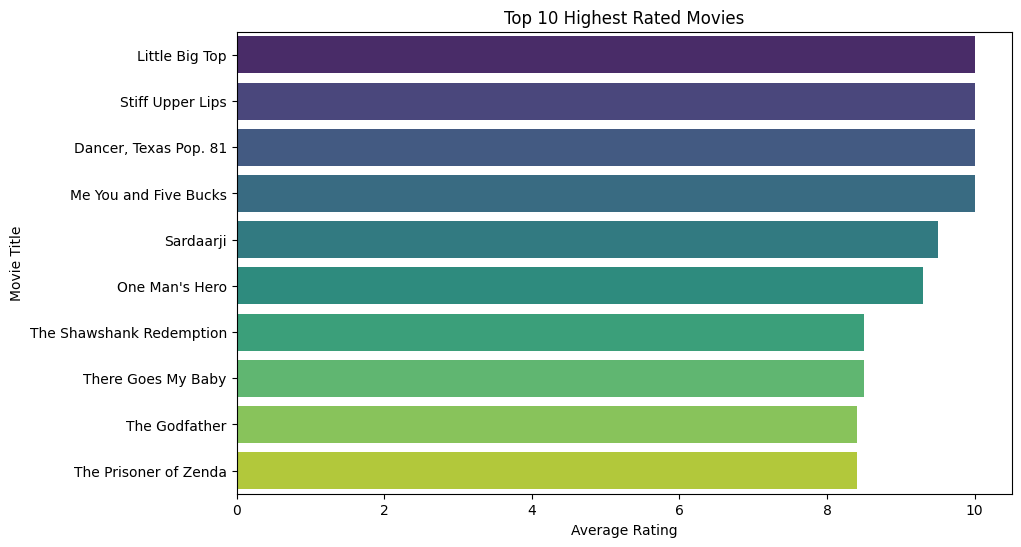

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x="vote_average", y="title", data=top_10_rated_movies, palette="viridis")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.title("Top 10 Highest Rated Movies")
plt.show()

In [14]:
# Top 10 most rated movies based on vote_count
top_10_most_voted_movies = movies.sort_values(by="vote_count", ascending=False).head(10)
print(top_10_most_voted_movies[["title", "vote_count"]])

                       title  vote_count
96                 Inception       13752
65           The Dark Knight       12002
0                     Avatar       11800
16              The Avengers       11776
788                 Deadpool       10995
95              Interstellar       10867
287         Django Unchained       10099
94   Guardians of the Galaxy        9742
426         The Hunger Games        9455
127       Mad Max: Fury Road        9427


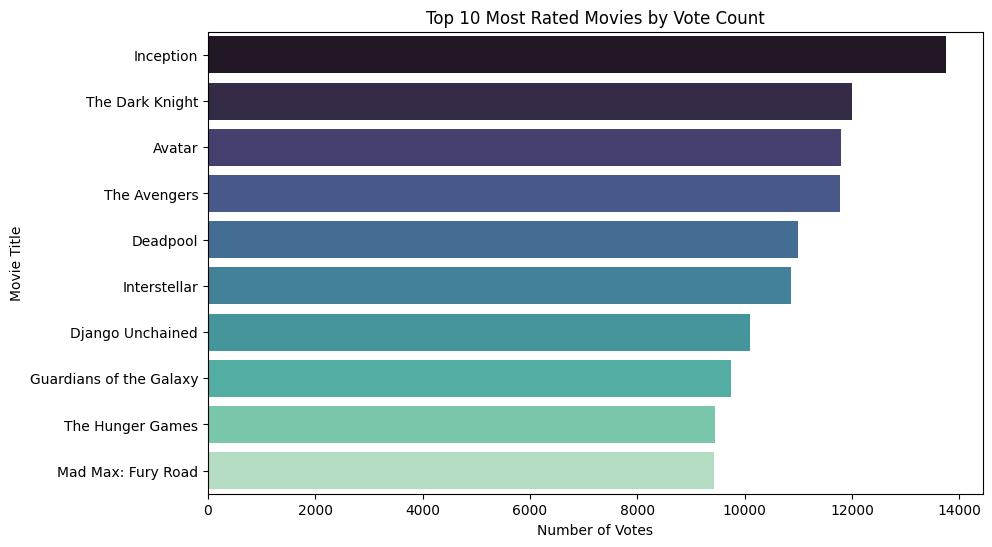

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x="vote_count", y="title", data=top_10_most_voted_movies, palette="mako", hue="title", legend=False)
plt.xlabel("Number of Votes")
plt.ylabel("Movie Title")
plt.title("Top 10 Most Rated Movies by Vote Count")
plt.show()

In [17]:
# Flatten the list of genres into a single Series
all_genres = movies['genres'].explode()

# Count the occurrences of each genre
genre_counts = all_genres.value_counts()

# Get the top 10 most popular genres
top_10_genres = genre_counts.head(10)

print("Top 10 Most Popular Genres:")
print(top_10_genres)

Top 10 Most Popular Genres:
genres
Drama              2297
Comedy             1722
Thriller           1274
Action             1154
Romance             894
Adventure           790
Crime               696
Science Fiction     535
Horror              519
Family              513
Name: count, dtype: int64


/tmp/ipykernel_760/4210903093.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette='Spectral')


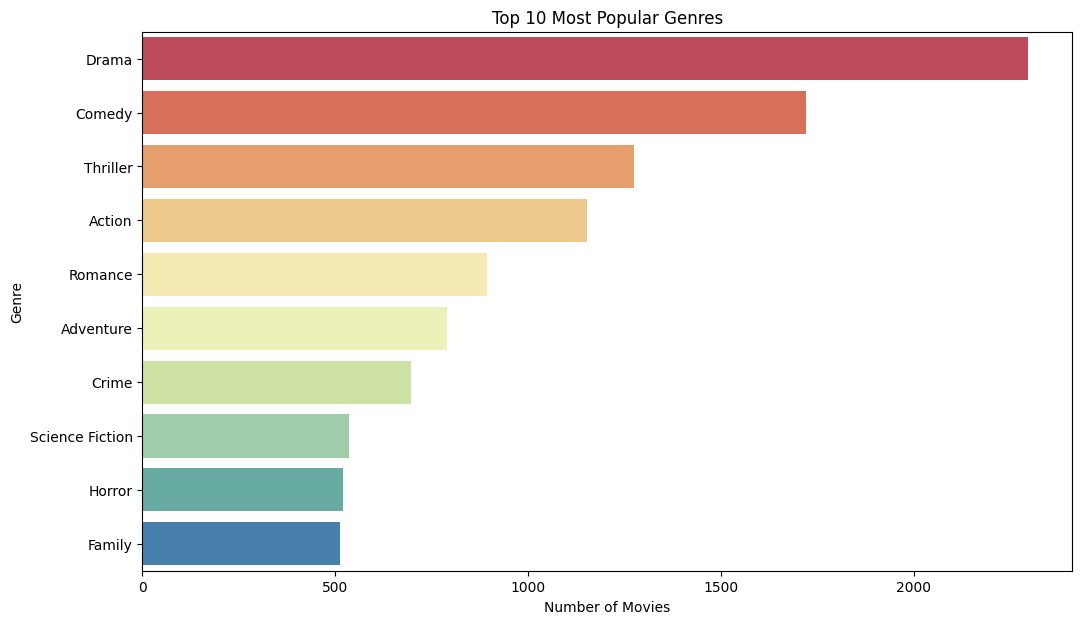

In [20]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette='Spectral')
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.title("Top 10 Most Popular Genres")
plt.show()

In [21]:
#insights and furthur analysis
print ("\ntop 10 most popular genres")
print(genre_counts)


top 10 most popular genres
genres
Drama              2297
Comedy             1722
Thriller           1274
Action             1154
Romance             894
Adventure           790
Crime               696
Science Fiction     535
Horror              519
Family              513
Fantasy             424
Mystery             348
Animation           234
History             197
Music               185
War                 144
Documentary         110
Western              82
Foreign              34
TV Movie              8
Name: count, dtype: int64
